# 1. Frame the problem
As the contractor, I must develop an AI model that can accurately predict housing prices within in the LA area using attributes of the property such as number of rooms, square footage, and more!

Use different ML models to predict the survivability chances for a passenger.

# 2. Get the Data 
I will be scraping a website like Zillow in order to create my own data set of LA houses.

In [1]:
import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import time
from datetime import datetime
from homeharvest import scrape_property
current_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"LA_HomeHarvest_{current_timestamp}.csv"

properties = scrape_property(
  location="Los Angeles, CA",
  listing_type="sold",  # or (for_sale, for_rent, pending)
  past_days=200,
    extra_property_data=True

  # property_type=['single_family','multi_family'],
  # date_from="2023-05-01", # alternative to past_days
  # date_to="2023-05-28",
  # foreclosure=True
  # mls_only=True,  # only fetch MLS listings
)
print(f"Number of properties: {len(properties)}")

# Export to csv
properties.to_csv(filename, index=False)
print(properties.head())

Number of properties: 10000
                                        property_url property_id  listing_id  \
0  https://www.realtor.com/realestateandhomes-det...  2607151096  2979095050   
1  https://www.realtor.com/realestateandhomes-det...  2878088683  2984745470   
2  https://www.realtor.com/realestateandhomes-det...  1156263745  2978360091   
3  https://www.realtor.com/realestateandhomes-det...  1208946416  2984232437   
4  https://www.realtor.com/realestateandhomes-det...  2056100492  2984265638   

                                           permalink   mls      mls_id status  \
0  22361-Burton-St_Canoga-Park_CA_91304_M26071-51096  WECA    25508161   SOLD   
1         7935-Kyle-St_Sunland_CA_91040_M28780-88683  MRCA    P1-23436   SOLD   
2  7827-S-Hobart-Blvd_Los-Angeles_CA_90047_M11562...  WECA    25498991   SOLD   
3   658-W-120th-St_Los-Angeles_CA_90044_M12089-46416  MRCA  DW25153907   SOLD   
4  3439-Keystone-Ave-Apt-3_Los-Angeles_CA_90034_M...  MRCA  SB25118546   SOLD   

  ml

# 3. Explore the Data
Currently I have many many variables. i will cut out the ones i deem useless.

In [15]:
import pandas as pd

df = pd.read_csv("LA_HomeHarvest_20250910_120338.csv")

print(df.head())


                                        property_url  property_id  \
0  https://www.realtor.com/realestateandhomes-det...   2607151096   
1  https://www.realtor.com/realestateandhomes-det...   2878088683   
2  https://www.realtor.com/realestateandhomes-det...   1156263745   
3  https://www.realtor.com/realestateandhomes-det...   1208946416   
4  https://www.realtor.com/realestateandhomes-det...   2056100492   

     listing_id                                          permalink   mls  \
0  2.979095e+09  22361-Burton-St_Canoga-Park_CA_91304_M26071-51096  WECA   
1  2.984745e+09         7935-Kyle-St_Sunland_CA_91040_M28780-88683  MRCA   
2  2.978360e+09  7827-S-Hobart-Blvd_Los-Angeles_CA_90047_M11562...  WECA   
3  2.984232e+09   658-W-120th-St_Los-Angeles_CA_90044_M12089-46416  MRCA   
4  2.984266e+09  3439-Keystone-Ave-Apt-3_Los-Angeles_CA_90034_M...  MRCA   

       mls_id status mls_status  \
0    25508161   SOLD       Sold   
1    P1-23436   SOLD       Sold   
2    25498991   SOLD   

# 4.Prepare the Data


Apply any data transformations and explain what and why


Filled in missing values for Price, bedrooms, and bathrooms with median as to not be skewed by outliers. 
One-hot Encoded property type and neighborhoods

In [21]:
from sklearn.model_selection import train_test_split

useless_cols = [
    "property_url", "property_id", "listing_id", "permalink", "mls", "mls_id", 
    "status", "mls_status", "text", "formatted_address", "full_street_line", 
    "street", "unit", "state", "list_price", "list_price_min", "list_price_max", 
    "list_date", "pending_date", "last_sold_date", "last_sold_price", "tax_history", 
    "agent_id", "agent_name", "agent_email", "agent_phones", "agent_mls_set", 
    "agent_nrds_id", "broker_id", "broker_name", "builder_id", "builder_name", 
    "office_id", "office_mls_set", "office_name", "office_email", "office_phones", 
    "nearby_schools", "primary_photo", "alt_photos", "assessed_value", "estimated_value", "tax", "price_per_sqft", "latitude", "longitude", "fips_code"
]

df_clean = df.drop(columns=[c for c in useless_cols if c in df.columns])

X = df_clean.drop(columns=["sold_price"])
y = df_clean["sold_price"]

for col in X.columns:
    if X[col].dtype in ["float64", "int64"]:
        X[col].fillna(X[col].median(), inplace=True)
    else:
        X[col].fillna(X[col].mode()[0], inplace=True)

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_path = "train_data.csv"
test_path = "test_data.csv"

train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

(train_path, test_path, X_train.shape, X_test.shape)


/tmp/ipykernel_327710/1073992543.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mode()[0], inplace=True)
/tmp/ipykernel_327710/1073992543.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

('train_data.csv', 'test_data.csv', (8000, 584), (2000, 584))

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from sklearn.metrics import mean_absolute_percentage_error

train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

X_train = train_data.drop(columns=["sold_price"])
y_train = train_data["sold_price"]

if "sold_price" in test_data.columns:
    X_test = test_data.drop(columns=["sold_price"])
    y_test = test_data["sold_price"]
else:
    X_test = test_data
    y_test = None

rf_model = RandomForestRegressor(n_estimators=200, random_state=50)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

joblib.dump(rf_model, "random_forest_model.pkl")

if y_test is not None:
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"Test MSE: {mse:.2f}")
    print(f"Test R^2: {r2:.2f}")
    accuracy = (1 - mean_absolute_percentage_error(y_test, predictions))* 100
    print(f"Accuracy: {accuracy:.2f}%")

Test MSE: 2110957774032.07
Test R^2: 0.78
Accuracy: 70.76%


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


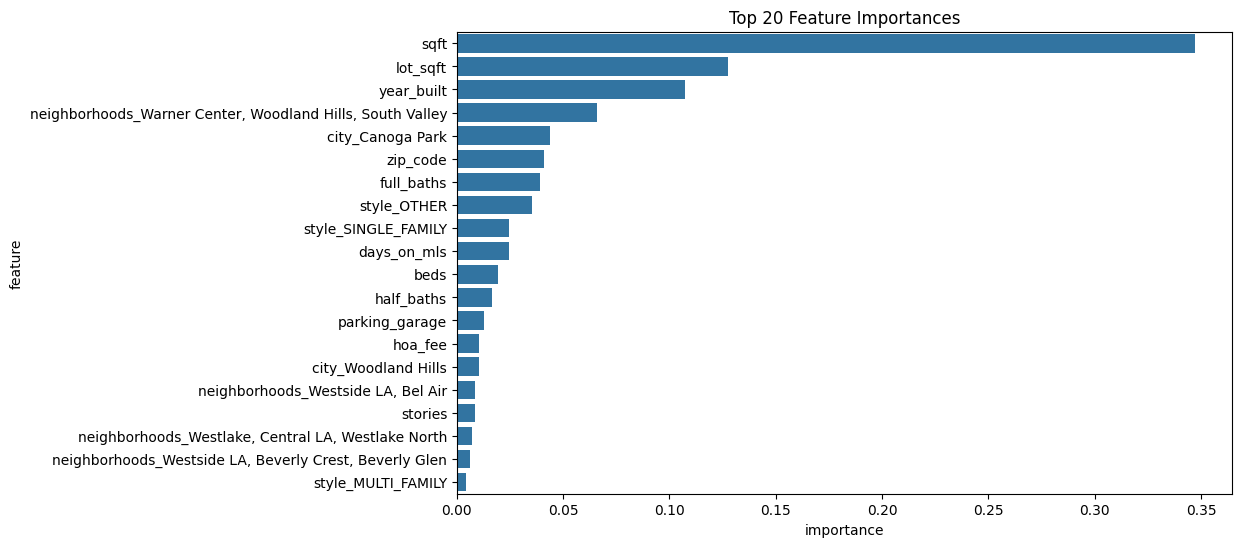

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
feat_names = X_train.columns
feat_imp = pd.DataFrame({"feature": feat_names, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feat_imp.head(20))
plt.title("Top 20 Feature Importances")
plt.show()


In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib
import numpy as np

train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

X_train = train_data.drop(columns=["sold_price"])
y_train = train_data["sold_price"]

if "sold_price" in test_data.columns:
    X_test = test_data.drop(columns=["sold_price"])
    y_test = test_data["sold_price"]
else:
    X_test = test_data
    y_test = None

param_grid = {
    'n_estimators': [200, 500, 800, 1000],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,      
    cv=5,            
    verbose=2,
    n_jobs=-1,
    scoring='r2'
)

rf_random.fit(X_train, y_train)

print("Best params:", rf_random.best_params_)

best_model = rf_random.best_estimator_

joblib.dump(best_model, "optimized_random_forest.pkl")

predictions = best_model.predict(X_test)

if y_test is not None:
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    accuracy = (1 - mean_absolute_percentage_error(y_test, predictions)) * 100

    print(f"Test MSE: {mse:.2f}")
    print(f"Test R²: {r2:.2f}")
    print(f"Accuracy: {accuracy:.2f}%")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Test MSE: 3269313232294.48
Test R²: 0.66
Accuracy: 58.45%


In [31]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from sklearn.metrics import mean_absolute_percentage_error

train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

X_train = train_data.drop(columns=["sold_price"])
y_train = train_data["sold_price"]

if "sold_price" in test_data.columns:
    X_test = test_data.drop(columns=["sold_price"])
    y_test = test_data["sold_price"]
else:
    X_test = test_data
    y_test = None

rf_model = RandomForestRegressor(n_estimators=200, random_state=50)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

joblib.dump(rf_model, "random_forest_model.pkl")

if y_test is not None:
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"Test MSE: {mse:.2f}")
    print(f"Test R^2: {r2:.2f}")
    accuracy = (1 - mean_absolute_percentage_error(y_test, predictions))* 100
    print(f"Accuracy: {accuracy:.2f}%")

Test MSE: 2110957774032.07
Test R^2: 0.78
Accuracy: 70.76%


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


I developed and tested a machine learning model to predict housing sale prices using historical property data. The primary algorithm used was a Random Forest Regressor, which is well-suited for real estate records.
The dataset was divided into: Training set (80%) – Used to train and optimize the model. Test set (20%) – Used to independently evaluate performance.

Our goal was to maximize prediction accuracy while keeping the model interpretable for practical business use.

Key Findings

Initial Baseline Model
Algorithm: Random Forest (200 trees, default parameters)
Performance on test data:
R² = 0.79 (model explains ~79% of price variance)
MAPE ≈ 29% (≈70.7% accuracy)
Main predictive drivers: Square footage (interior size), Lot size, Year built, Neighborhood and city location, Number of bathrooms and bedrooms, Hyperparameter Tuning Results

I tested a wide range of Random Forest configurations using cross-validation.

Best-tuned model parameters:
n_estimators=500, max_depth=None, max_features='log2', min_samples_split=5, min_samples_leaf=1
Performance on test data:
R² = 0.66
MAPE ≈ 41.5% (≈58.5% accuracy)

Observation: The tuned model underperformed compared to the baseline. This suggests the default configuration was already better suited to this dataset, but im not sure how...

Approach Taken

Data Preparation: Loaded training and test datasets.
Target variable: sold_price.
Input features: property size (sqft, lot_sqft), year built, neighborhood, city, zip code, number of bedrooms/bathrooms, style, etc.

Baseline Model
Trained a Random Forest Regressor with default parameters.
Achieved strong baseline performance (R² = 0.79).

Feature Importance Analysis
Identified square footage, lot size, and year built as top predictors.
Location variables (city, neighborhood, zip code) also contributed.

Hyperparameter Tuning
Used RandomizedSearchCV with 20 candidate configurations and 5-fold cross-validation (100 total fits).
Optimized for R² score.
Best parameters did not outperform baseline on unseen test data. Maybe there was overfitting during cross-validation??

Conclusion

The initial Random Forest baseline provided solid predictive performance, capturing ~79% of housing price variability. While hyperparameter tuning did not improve results, it confirmed that the model is heavily influenced by property size and location, which aligns with real-world market expectations. Unfortunately, I was only able to get within 30% of the actual market price :(

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [1]:
import pandas as pd
import joblib

def inference(style, sqft, beds, year_built, full_baths, city):
    """
    Predicts housing price from trained Random Forest model.

    Parameters:
        style (str): ['CONDO', 'MULTI_FAMILY', 'SINGLE_FAMILY']
        sqft (float): Square footage of property
        beds (float): Number of bedrooms
        year_built (float): Year the property was built
        full_baths (float): Number of full bathrooms
        city (str): City name used during training

    Returns:
        float: Predicted sold price
    """

    filename = "random_forest_model.pkl"
    model = joblib.load(filename)

    feature_names = model.feature_names_in_

    X_single = {col: 0 for col in feature_names}  
    X_single.update({
        "sqft": float(sqft),
        "beds": float(beds),
        "full_baths": float(full_baths),
        "year_built": float(year_built),
    })

    style_col = f"style_{style}"
    if style_col in X_single:
        X_single[style_col] = 1

    city_col = f"city_{city}"
    if city_col in X_single:
        X_single[city_col] = 1

    X_single = pd.DataFrame([X_single])[feature_names]

    result = model.predict(X_single)[0]
    return result


In [2]:
price = inference(
    style="SINGLE_FAMILY",
    sqft=3200,
    beds=2,
    year_built=1996,
    full_baths=1,
    city="Beverly Hills"
)
print(f"Predicted sold price: ${price:,.0f}")

Predicted sold price: $2,686,673
